## Suzuki-Miyaura Yield Benchmark

In [1]:

from ChemBart import CB_Regression
import json
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import numpy as np


[2026-04-18 10:10:55,351] [INFO] [real_accelerator.py:203:get_accelerator] Setting ds_accelerator to cuda (auto detect)
 [WARNING]  Please specify the CUTLASS repo directory as environment variable $CUTLASS_PATH
 [WARNING]  using untested triton version (3.0.0), only 1.0.0 is known to be compatible


In [5]:

def make_plot(y_test, y_pred, name):

    fontsize = 28
    label_fontsize = 32
    tick_fontsize = 26
    

    fig, ax = plt.subplots(figsize=(10, 9))
    

    rmse = mean_squared_error(y_test, y_pred, squared=False)
    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)

    metrics_text = f"R² = {r2:.3f}\nRMSE = {rmse:.1f}\nMAE = {mae:.1f}"
    

    plt.xlim(-5, 105)
    plt.ylim(-5, 105)
    

    plt.scatter(y_pred, y_test, alpha=0.4, color="#1f77b4", s=60)  # 调整点的大小和透明度
    

    plt.plot(np.arange(100), np.arange(100), ls="--", c=".3", linewidth=2)
    

    ax.text(0.05, 0.95, metrics_text, 
            transform=ax.transAxes,
            ha='left', va='top',
            fontsize=fontsize,
            bbox=dict(facecolor='white', alpha=0.8, boxstyle='round,pad=0.5'))
    

    ax.set_ylabel('True', fontsize=label_fontsize)
    ax.set_xlabel('Predicted', fontsize=label_fontsize)
    ax.set_title(name, fontsize=label_fontsize)  # 增加标题间距
    

    plt.tick_params(axis='both', which='major', labelsize=tick_fontsize)
    
    plt.tight_layout()
    
    plt.show()

In [2]:
import json
import os

input_base_dir = 'data/yield/Suzuki-Miyaura_splits'
output_base_dir = 'data/yield/SM_cleaned'

os.makedirs(output_base_dir, exist_ok=True)

for i in range(10):
    json_file_path = f'{input_base_dir}/sm{i}.json'
    cleaned_file_path = f'{output_base_dir}/sm{i}.json'

    if not os.path.exists(json_file_path):
        print(f"not found - {json_file_path}")
        continue

    with open(json_file_path, 'r') as f:
        data = json.load(f)

    yields = []
    cleaned_data = []

    for item in data:
        try:
            reaction, yield_list = item
            yield_value = yield_list[0] 

            if isinstance(yield_value, (int, float)) and yield_value > 0.01:
                yields.append(yield_value)
                cleaned_data.append(item)
        except (IndexError, ValueError, TypeError) as e:
            print(f"warning - {item}, error: {e}")
            continue

    # 统计信息
    print(f"\n--- sm{i}.json ---")
    print(f"origin data: {len(data)}")
    print(f"cleaned data: {len(cleaned_data)}")
    if yields:
        print(f"  min: {min(yields):.2f}")
        print(f"  max: {max(yields):.2f}")
        print(f"  mean: {sum(yields)/len(yields):.2f}")
        print(f"  median: {sorted(yields)[len(yields)//2]:.2f}")
    else:
        print("清洗后无有效产率数据")

    # 保存清洗后的数据
    with open(cleaned_file_path, 'w') as f:
        json.dump(cleaned_data, f, indent=2)

    print(f"saved: {cleaned_file_path}")

print("\nfinished cleaning all files.")



--- sm0.json ---
origin data: 5760
cleaned data: 5469
  min: 0.01
  max: 1.00
  mean: 0.42
  median: 0.36
saved: data/yield/SM_cleaned/sm0.json

--- sm1.json ---
origin data: 5760
cleaned data: 5469
  min: 0.01
  max: 1.00
  mean: 0.42
  median: 0.36
saved: data/yield/SM_cleaned/sm1.json

--- sm2.json ---
origin data: 5760
cleaned data: 5469
  min: 0.01
  max: 1.00
  mean: 0.42
  median: 0.36
saved: data/yield/SM_cleaned/sm2.json

--- sm3.json ---
origin data: 5760
cleaned data: 5469
  min: 0.01
  max: 1.00
  mean: 0.42
  median: 0.36
saved: data/yield/SM_cleaned/sm3.json

--- sm4.json ---
origin data: 5760
cleaned data: 5469
  min: 0.01
  max: 1.00
  mean: 0.42
  median: 0.36
saved: data/yield/SM_cleaned/sm4.json

--- sm5.json ---
origin data: 5760
cleaned data: 5469
  min: 0.01
  max: 1.00
  mean: 0.42
  median: 0.36
saved: data/yield/SM_cleaned/sm5.json

--- sm6.json ---
origin data: 5760
cleaned data: 5469
  min: 0.01
  max: 1.00
  mean: 0.42
  median: 0.36
saved: data/yield/SM_cl

In [3]:
json_file_path = 'data/yield/SM_cleaned/sm0.json'
with open(json_file_path, 'r') as f:
    data = json.load(f)

max([len(item[0]) for item in data])

268

In [ ]:
#train
#train：validation：test 6：1：3
from ChemBart import CB_Regression
import json
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import numpy as np

TRAIN = True
LABEL_NUM = 1

task_token = ["<n00>", "<n01>", "<n02>","<n03>", "<n04>"]
ends = "".join(task_token[:LABEL_NUM - 1]) + "<end>"

for i in range(0, 10):
    json_file_path = f'data/yield/SM_cleaned/sm{i}.json'
    model_name = f"Suzuki-Miyaura_cleaned{i}"
    c = CB_Regression(name = model_name, pre_model='ChemBart_MIT_6',label_num = LABEL_NUM, device = "cuda:2") #"cuda:0", "cuda:1" etc.
    with open(json_file_path) as f:
        l = json.load(f)
    for i in range(len(l)):
        l[i][0] += ends
    print(l[1])

    train_prop = 0.6
    valid_prop = 0.1

    train_size = int(train_prop*len(l))
    valid_size = int(valid_prop*len(l))
    test_size = len(l) - train_size - valid_size

    labels = [item[1] for item in l]
    train_labels = labels[:train_size]
    mean = np.mean(train_labels)
    std = np.std(train_labels)
    standardized_labels = [(label - mean) / std for label in labels]
    for i, item in enumerate(l):
        l[i][1] = [float(standardized_labels[i])]
    print(l[1])

    if TRAIN:
        c.fit(data = l[0:train_size+valid_size], epoch = 1000, batch_size = 4, tr=train_size, val=valid_size, te = test_size, id_maxlen =300 )
        #data, epoch, batch size, train num, val num, test num, max input length
    else:
        out = c.test(l[-test_size:-1], batch_size = 4)
        print(out)
    
    (RMSE_list, reslist) = c.test(l[-test_size:-1], batch_size = 4)

    y_pred, y_test = [], []
    for sublist in reslist:
        if all(isinstance(item, tuple) and len(item) == 2 for item in sublist):
            y_pred.extend([(item[0] * std + mean)*100 for item in sublist])
            y_pred = np.clip(y_pred, 0, 100)
            y_test.extend([(item[1] * std + mean)*100 for item in sublist])
        else:
            raise ValueError("Each element in sublist must be a tuple of length 2.")
    plot = make_plot(y_test, y_pred, model_name)

fine-tuned model Suzuki-Miyaura_cleaned0.pth


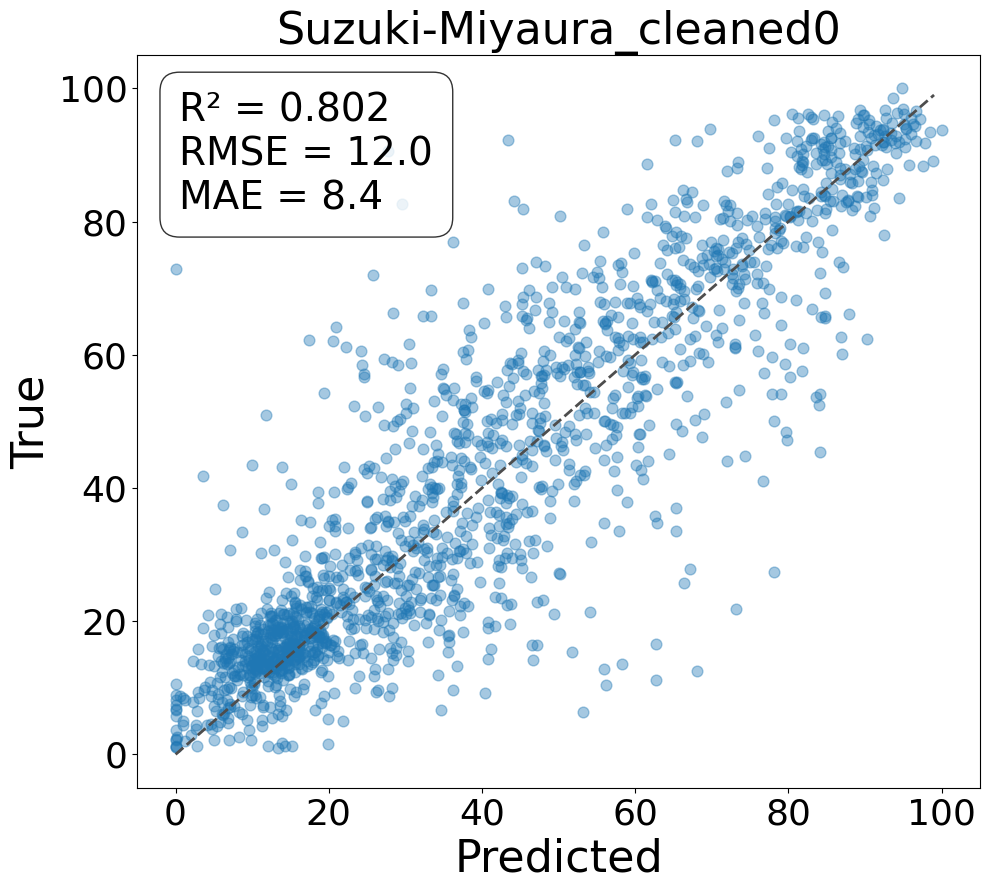

fine-tuned model Suzuki-Miyaura_cleaned1.pth


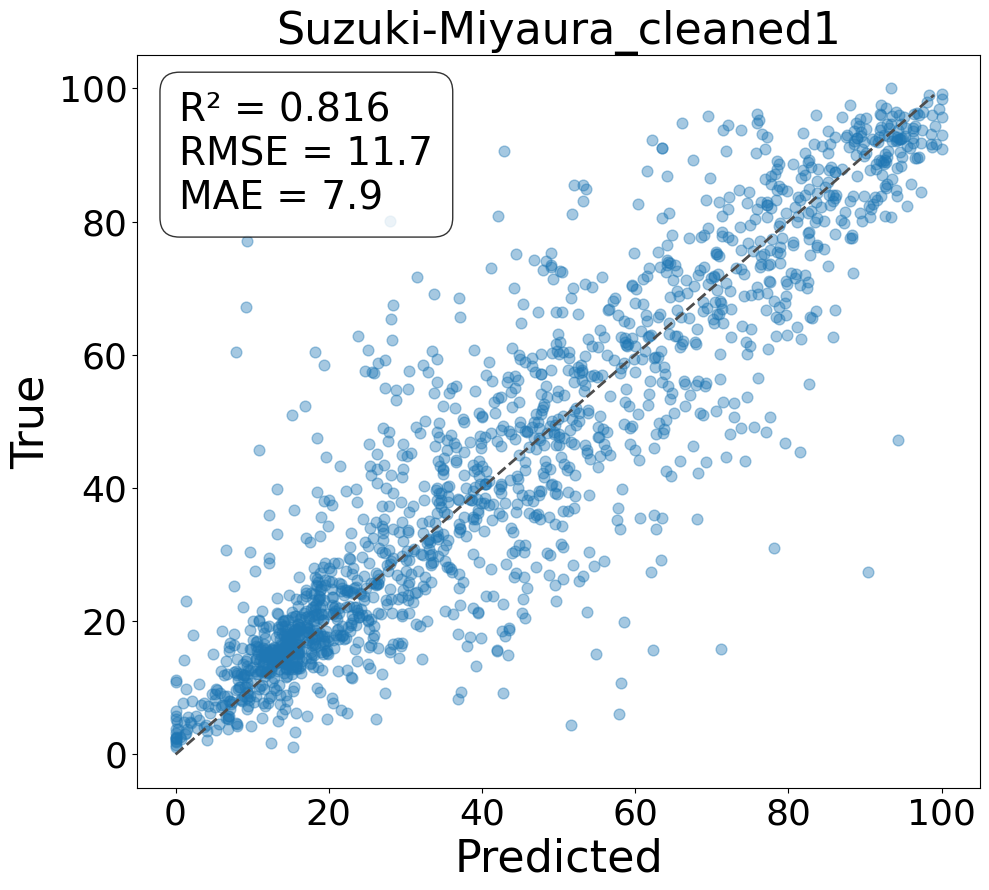

fine-tuned model Suzuki-Miyaura_cleaned2.pth


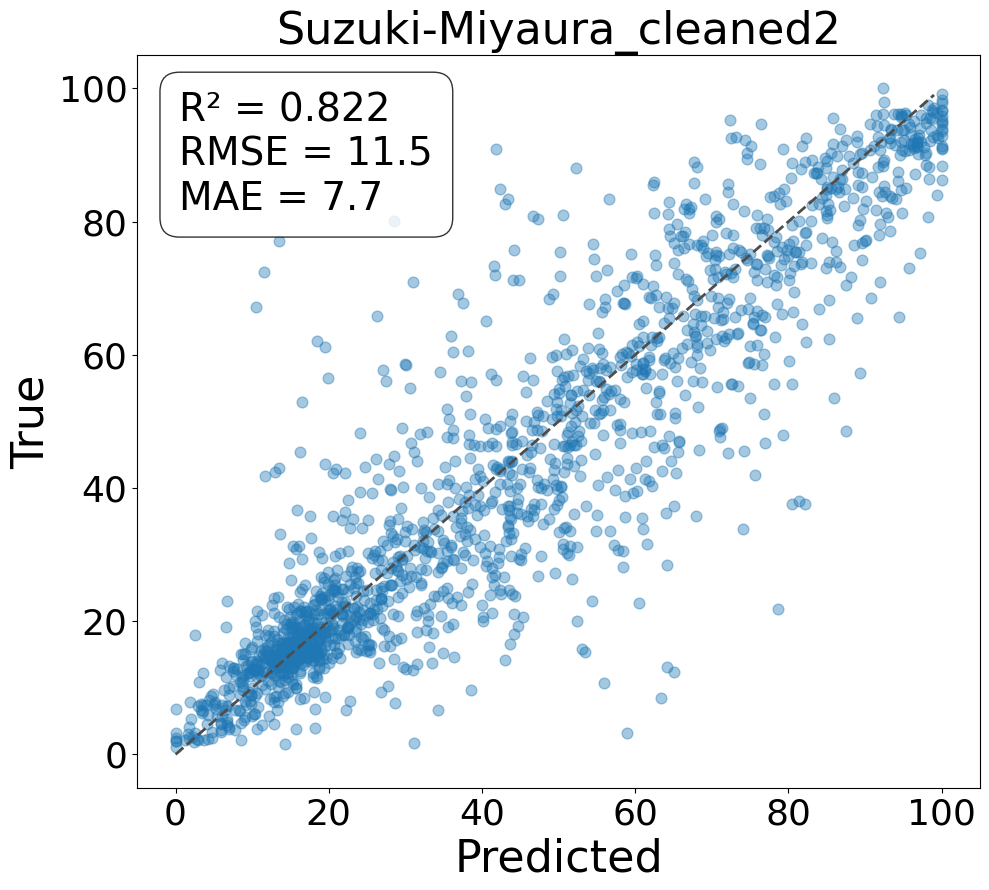

fine-tuned model Suzuki-Miyaura_cleaned3.pth


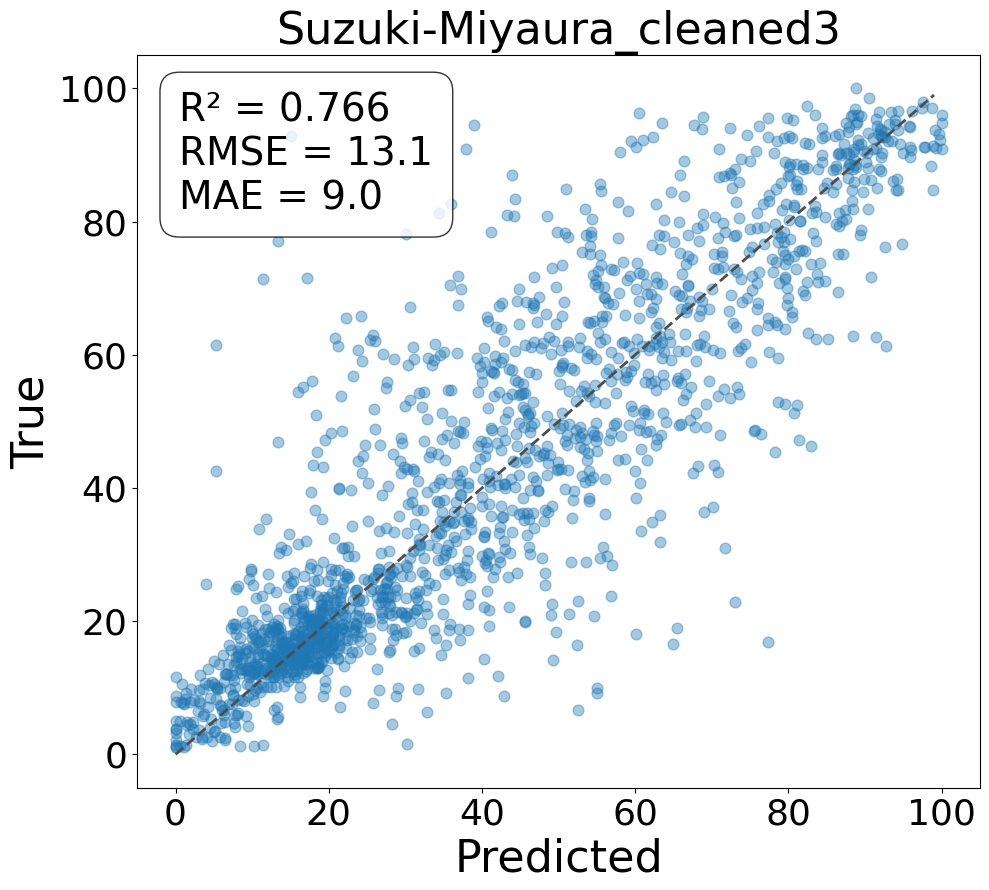

fine-tuned model Suzuki-Miyaura_cleaned4.pth


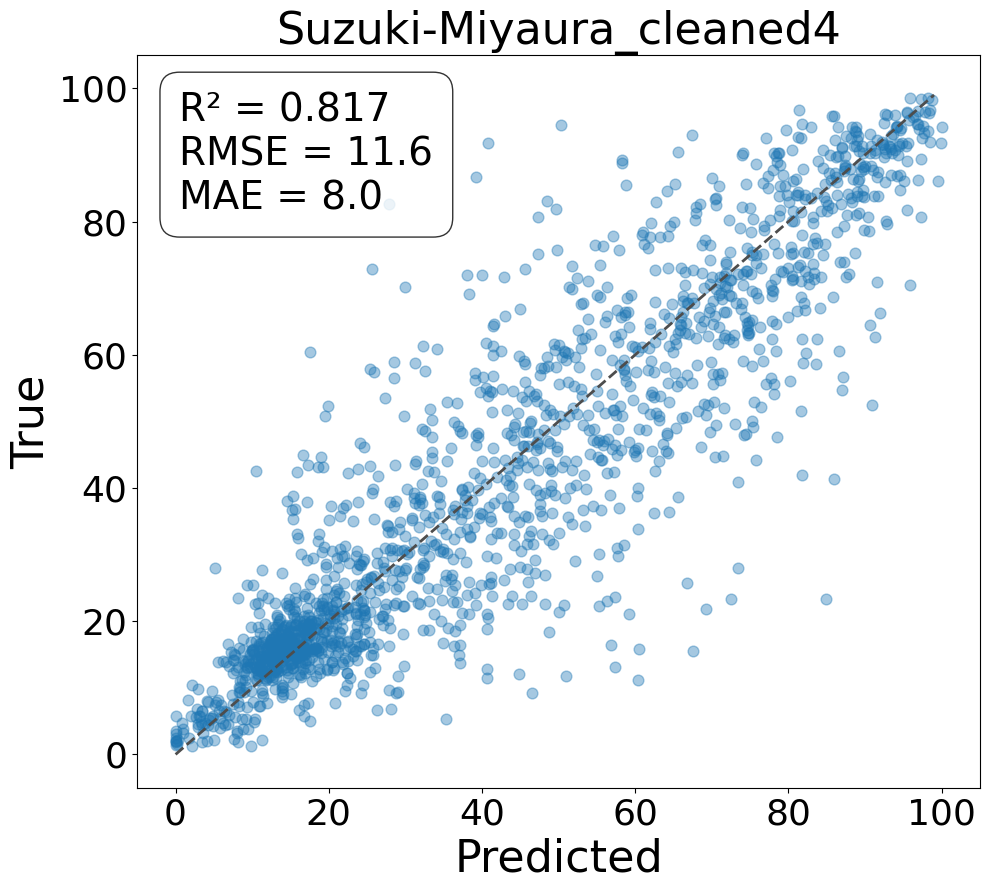

fine-tuned model Suzuki-Miyaura_cleaned5.pth


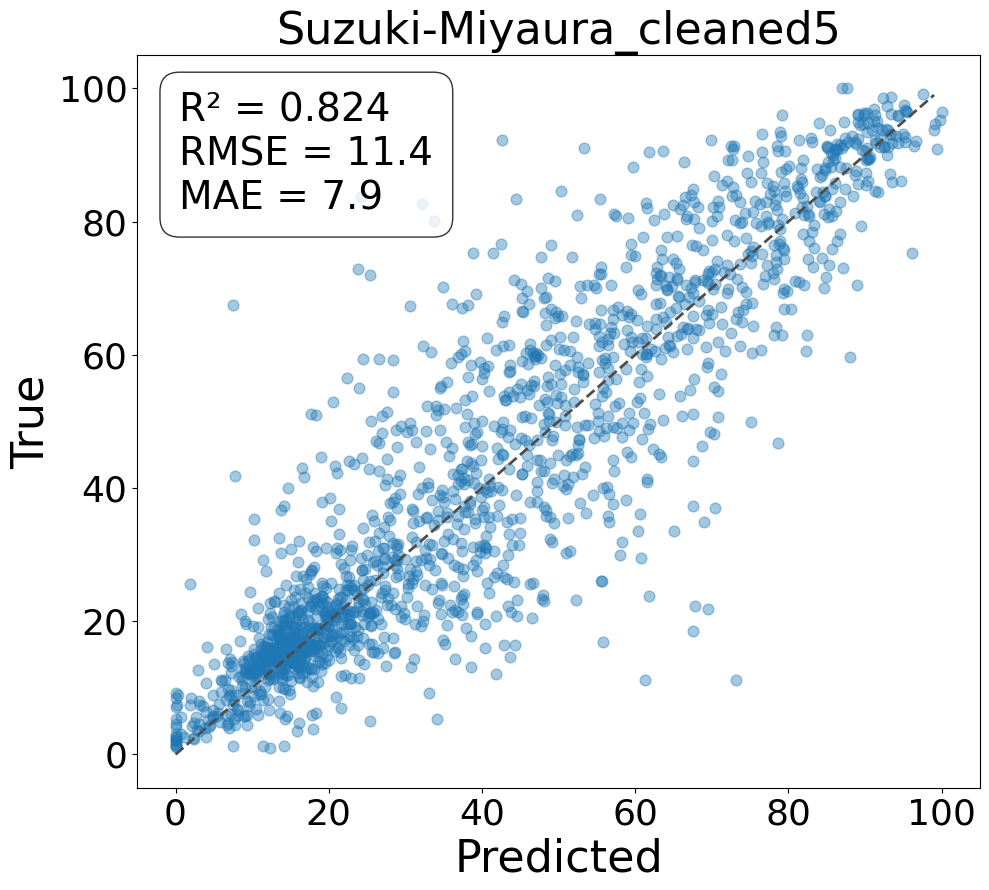

fine-tuned model Suzuki-Miyaura_cleaned6.pth


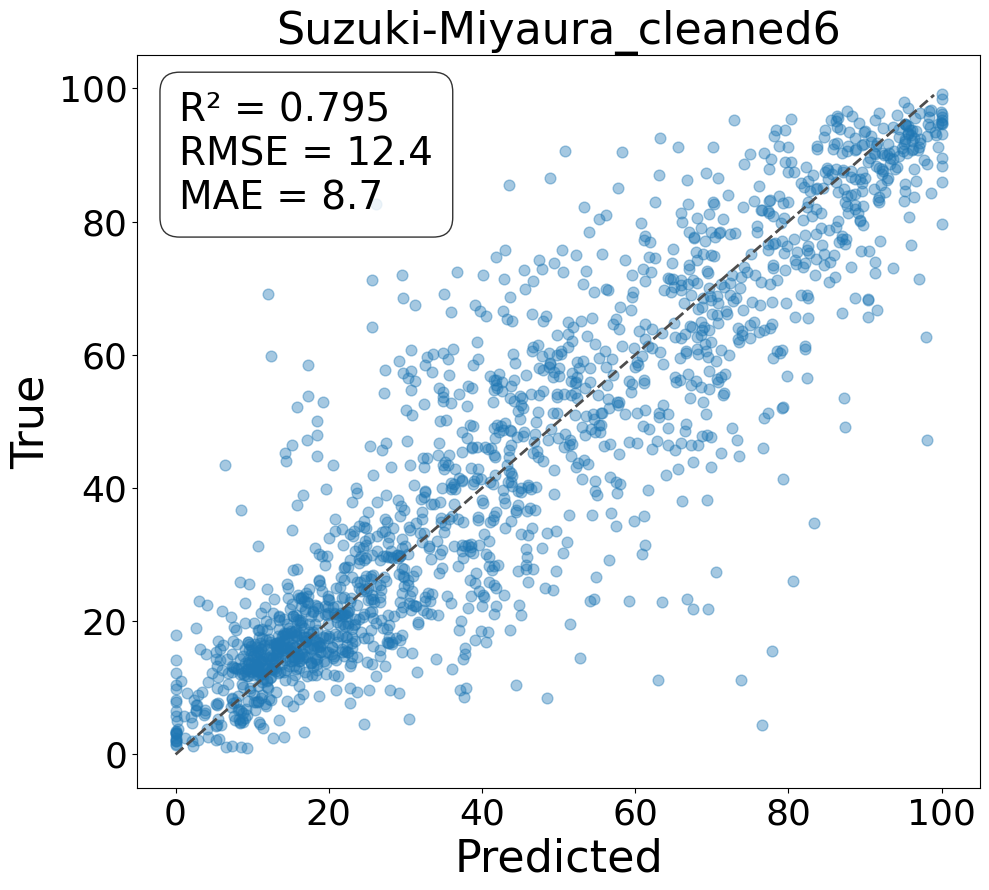

fine-tuned model Suzuki-Miyaura_cleaned7.pth


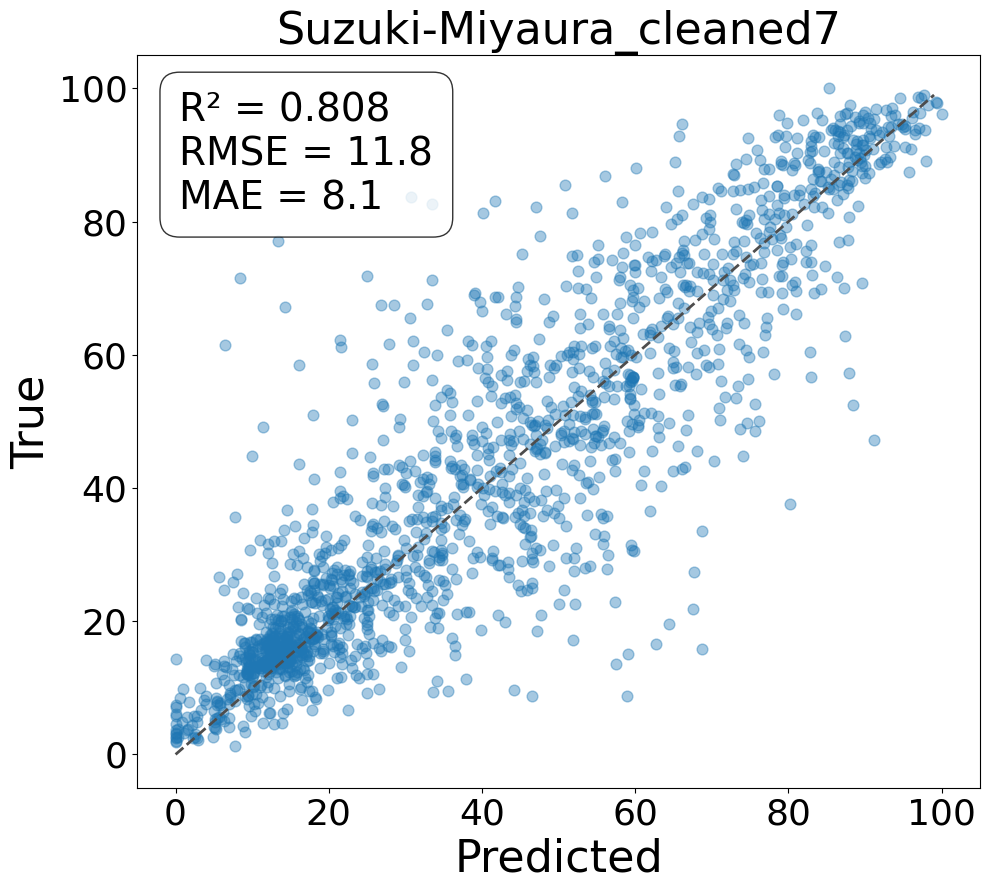

fine-tuned model Suzuki-Miyaura_cleaned8.pth


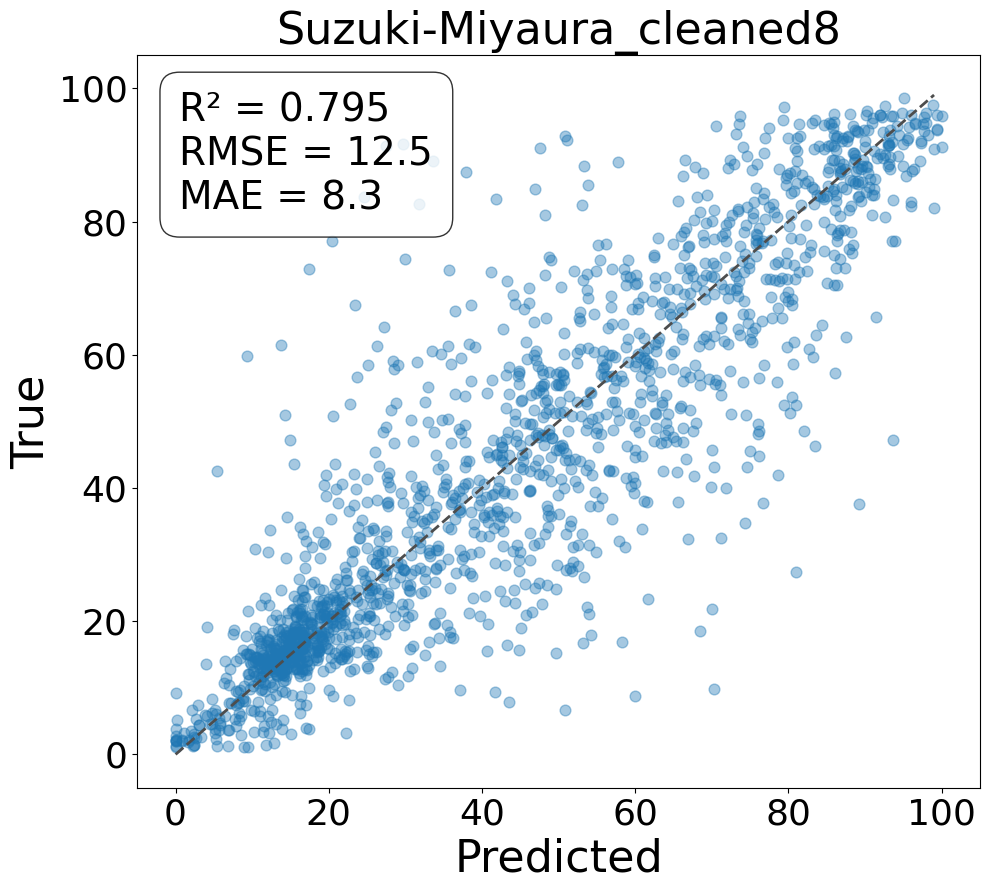

fine-tuned model Suzuki-Miyaura_cleaned9.pth


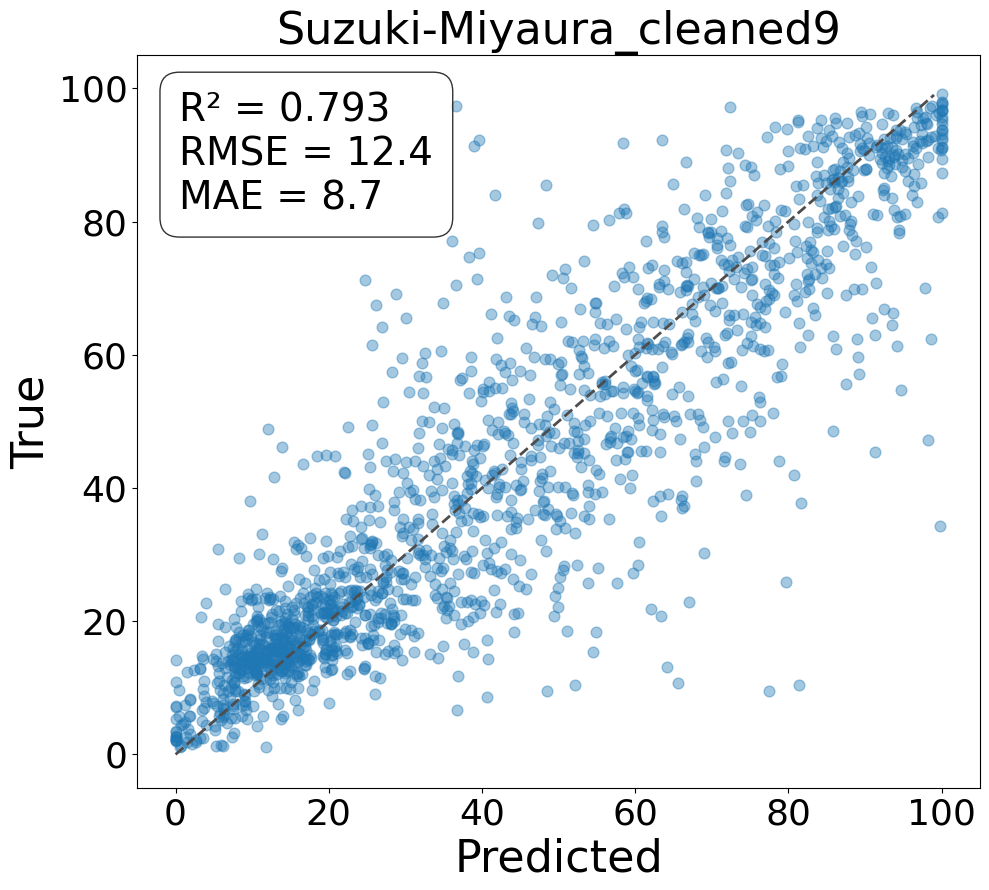

In [6]:
#test
from ChemBart import CB_Regression
import json
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import numpy as np

TRAIN = False
LABEL_NUM = 1

task_token = ["<n00>", "<n01>", "<n02>","<n03>", "<n04>"]
ends = "".join(task_token[:LABEL_NUM - 1]) + "<end>"

for i in range(0, 10):
    json_file_path = f'data/yield/SM_cleaned/sm{i}.json'
    model_name = f"Suzuki-Miyaura_cleaned{i}"
    c = CB_Regression(name = model_name, pre_model='ChemBart_MIT_6',label_num = LABEL_NUM, device = "cuda:2") #"cuda:0", "cuda:1" etc.
    with open(json_file_path) as f:
        l = json.load(f)
    for i in range(len(l)):
        l[i][0] += ends
    #print(l[1])

  
    train_prop = 0.6
    valid_prop = 0.1

    train_size = int(train_prop*len(l))
    valid_size = int(valid_prop*len(l))
    test_size = len(l) - train_size - valid_size


    labels = [item[1] for item in l]
    train_labels = labels[:train_size]
    mean = np.mean(train_labels)
    std = np.std(train_labels)

    standardized_labels = [(label - mean) / std for label in labels]
  
    for i, item in enumerate(l):
        l[i][1] = [float(standardized_labels[i])]
    #print(l[1])

    if TRAIN:
        c.fit(data = l[0:train_size+valid_size], epoch = 1000, batch_size = 4, tr=train_size, val=valid_size, te = test_size, id_maxlen =300 )
        #data, epoch, batch size, train num, val num, test num, max input length
    else:
        out = c.test(l[-test_size:-1], batch_size = 4)
        #print(out)
    
    (RMSE_list, reslist) = c.test(l[-test_size:-1], batch_size = 4)


    y_pred, y_test = [], []
    for sublist in reslist:
        if all(isinstance(item, tuple) and len(item) == 2 for item in sublist):
            y_pred.extend([(item[0] * std + mean)*100 for item in sublist])
            y_pred = np.clip(y_pred, 0, 100)
            y_test.extend([(item[1] * std + mean)*100 for item in sublist])
        else:
            raise ValueError("Each element in sublist must be a tuple of length 2.")
    plot = make_plot(y_test, y_pred, model_name)